### DEM Derivatives
Calcul de toutes les couches terrain dérivées depuis le DEM local (`data/mono_dem.tif`).

In [30]:
import sys, os
sys.path.insert(0, os.path.abspath("."))  # rend durpy et derivedDem importables
#sys.path.insert(0, r"D:\REPOSITORY\FloodRM")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

from durpy.derivedDem import (
    init_local_engine,
    derive_slope,
    derive_aspect,
    derive_curvature,
    derive_twi,
    derive_flow_accumulation,
    derive_drainage_density,
    derive_dist_to_river,
    load_rain_v2,
    load_lulc,
)

from durpy.variables import WC_LEGEND

DEM_PATH = "data/mono_dem.tif"
init_local_engine(DEM_PATH)

DEM chargé : (11010, 4500) | ext=[0.687639184, 1.937639284, 6.279305658, 9.337639236]


In [31]:
slope,  ext = derive_slope()
aspect, ext = derive_aspect()
curv,   ext = derive_curvature()
twi,    ext = derive_twi()
facc,   ext = derive_flow_accumulation()
density, ext = derive_drainage_density()
distRiver, ext = derive_dist_to_river()

🗺️  raster enregistré : .\_tmp_dem_pysheds.tif


In [32]:
lulc, ext = load_lulc("data/lulc_esa.tif")
rain, ext = load_rain_v2("data/chirps_daily_1985_2023.nc")

Pluie annuelle cumul moyen : min=921.0 mm/an | max=1709.0 mm/an


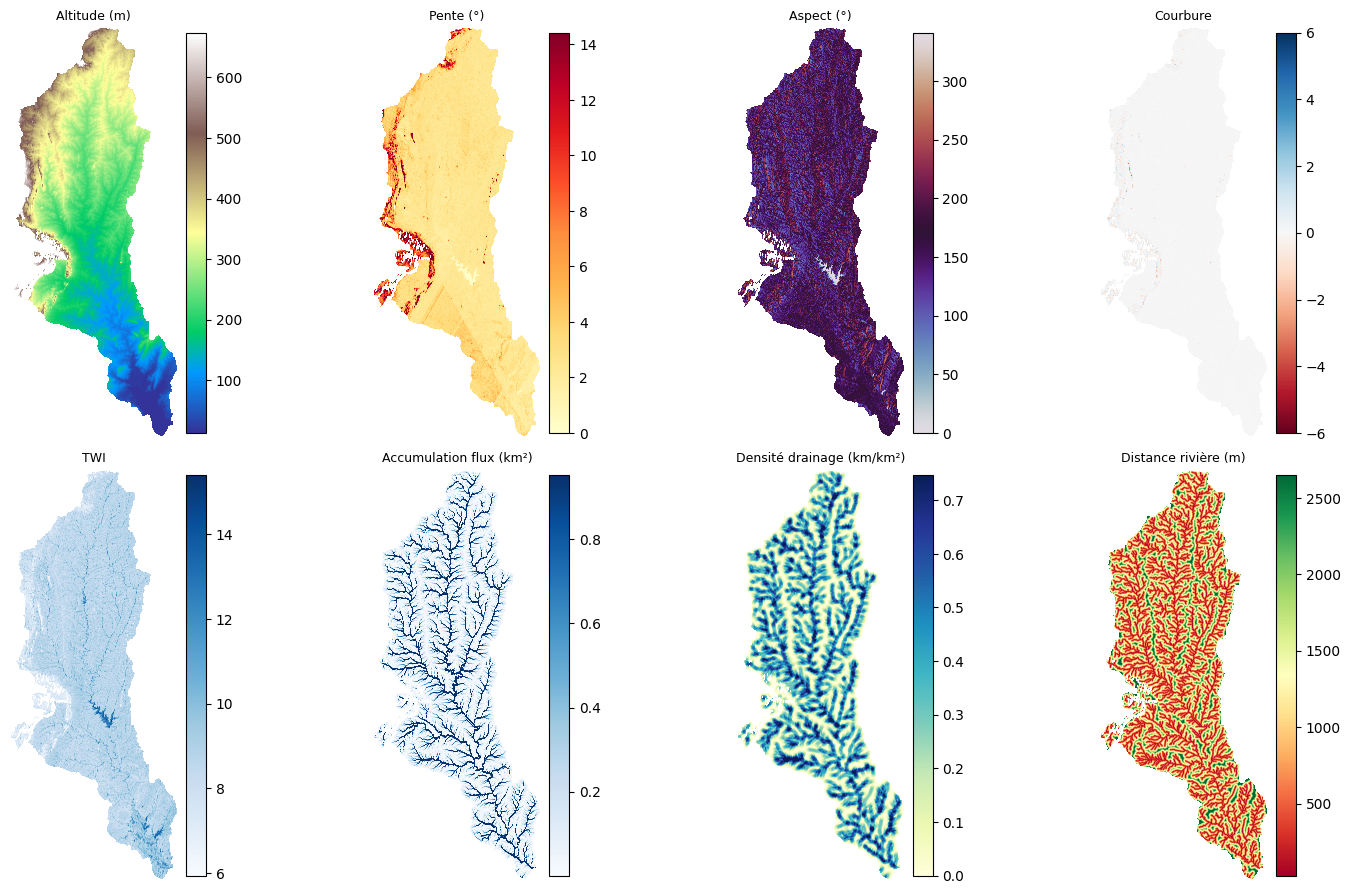

In [33]:
from durpy.variables import LAYERS

elev = LAYERS["elevation"]

layers = {
    "Altitude (m)":              (elev,      "terrain"),
    "Pente (°)":                 (slope,     "YlOrRd"),
    "Aspect (°)":                (aspect,    "twilight"),
    "Courbure":                  (curv,      "RdBu"),
    "TWI":                       (twi,       "Blues"),
    "Accumulation flux (km²)":   (facc,      "Blues"),
    "Densité drainage (km/km²)": (density,   "YlGnBu"),
    "Distance rivière (m)":      (distRiver, "RdYlGn"),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, (title, (arr, cmap)) in zip(axes.flat, layers.items()):
    im = ax.imshow(
        arr, cmap=cmap,
        vmin=np.nanpercentile(arr, 2),
        vmax=np.nanpercentile(arr, 98),
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

#plt.suptitle("Couches dérivées du DEM", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
lulc, ext = load_lulc("data/lulc_esa.tif")

codes  = sorted(WC_LEGEND.keys())
colors = [WC_LEGEND[c][1] for c in codes]
cmap   = ListedColormap(colors)
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(lulc, cmap=cmap, vmin=codes[0]-5, vmax=codes[-1]+5)
patches = [Patch(color=WC_LEGEND[c][1], label=WC_LEGEND[c][0]) for c in codes]
#ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
#ax.set_title("Land Use / Land Cover"); ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(rain, cmap="YlGnBu",
               vmin=np.nanpercentile(rain, 2),
               vmax=np.nanpercentile(rain, 98))
ax.set_title("Pluie annuelle moyenne")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, label="mm/an")
plt.tight_layout()
plt.show()


### AHP for Flood Risk Mapping
Workflow complet : normalisation → reclassification → poids → FIPS → zones de risque.

In [4]:
from durpy.ahp import (
    normalize_all, compute_scores, compute_weights,
    compute_flood_index, classify_flood_index, sensitivity_analysis,
)
from durpy.ahp_config import RECLASS, AHP_CRITERIA, AHP_PAIRS, AHP_INCLUDE, NORM_KEYS
from durpy.variables import LAYERS, SCORE_LEGEND

In [ ]:
# --- ETAPE 1 : Normalisation 0-1 ---
# Methodes disponibles : minmax | robust | zscore | fuzzy_linear | fuzzy_sigmoidal
NORM_METHOD = "minmax"

print("Normalisation des couches :", NORM_KEYS)
stats_df = normalize_all(NORM_KEYS, method=NORM_METHOD)
print("Statistiques :")
print(stats_df.to_string(index=False))


In [ ]:
# --- ETAPE 2 : Reclassification -> scores 1-5 ---
# RECLASS_INPUT = "raw"       -> utilise les couches brutes
# RECLASS_INPUT = "normalized" -> utilise les couches normalisees
RECLASS_INPUT = "raw"
use_norm = RECLASS_INPUT == "normalized"

print("Reclassification des facteurs :")
SCORES = compute_scores(RECLASS, AHP_INCLUDE, use_norm=use_norm)
print(f"{len(SCORES)} facteurs scores : {list(SCORES.keys())}")


In [ ]:
# --- ETAPE 3 : Poids AHP (matrice de Saaty) ---
# Si CR > 0.10 : ajuster AHP_PAIRS dans durpy/ahp_config.py
weights = compute_weights(AHP_PAIRS, AHP_CRITERIA, AHP_INCLUDE, SCORES)


In [8]:
# --- ETAPE 4 : Indice de risque (FIPS) ---
fips = compute_flood_index(SCORES, weights)
print(f"FIPS : min={float(np.nanmin(fips)):.3f} | max={float(np.nanmax(fips)):.3f} | mean={float(np.nanmean(fips)):.3f}")


FIPS : min=0.676 | max=4.937 | mean=2.673


In [9]:
# --- ETAPE 5 : Classification en zones de risque ---
# method = "equal" (seuils fixes 1.8/2.6/3.4/4.2) ou "quantile"
zones, breaks = classify_flood_index(fips, method="equal")
LAYERS["flood_risk"] = zones


Seuils zones : [1.8, 2.6, 3.4, 4.2]


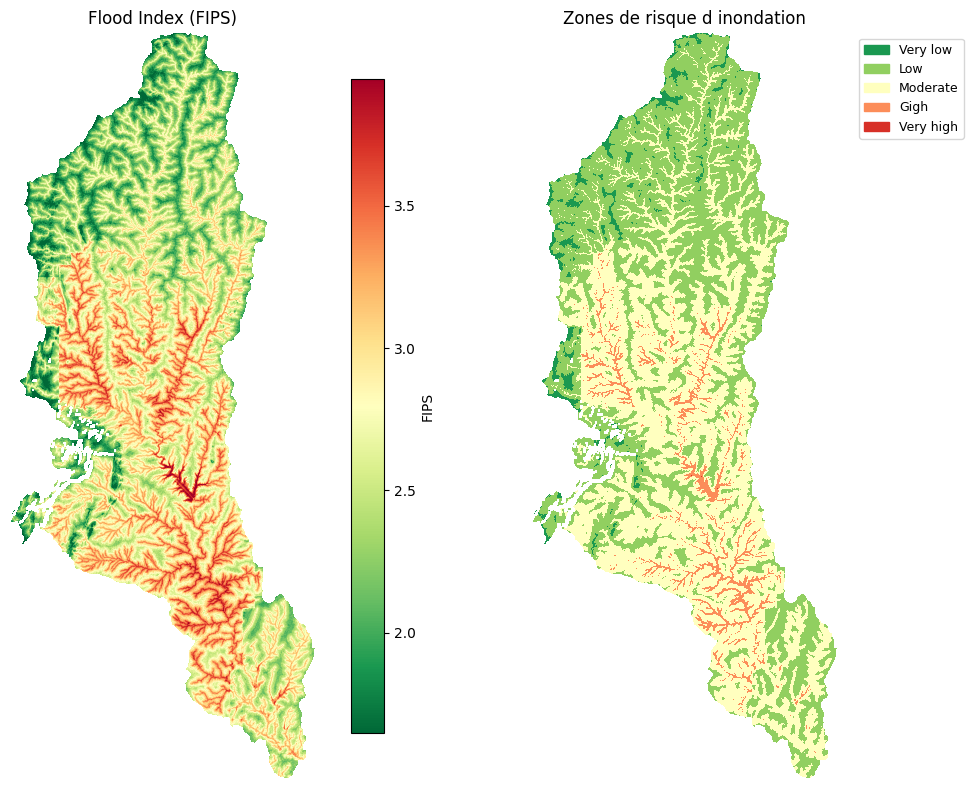

In [27]:
# --- ETAPE 6 : Visualisation FIPS + zones ---
zone_colors = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
zone_labels = ["Very low", "Low", "Moderate", "Gigh", "Very high"]
cmap_zones = ListedColormap(zone_colors)
cmap_zones.set_bad(alpha=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# FIPS continu
im0 = axes[0].imshow(fips, cmap="RdYlGn_r", vmin=np.nanpercentile(fips, 2),
                     vmax=np.nanpercentile(fips, 98))
axes[0].set_title("Flood Index (FIPS)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="FIPS")

# Zones discretes
im1 = axes[1].imshow(zones, cmap=cmap_zones, vmin=0.5, vmax=5.5)
axes[1].set_title("Zones de risque d inondation")
axes[1].axis("off")
patches = [Patch(color=zone_colors[i], label=zone_labels[i]) for i in range(5)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :
 rank         criterion  weight_%  MAD_FIPS
    1 flow_accumulation     17.10    0.2210
    2        rain_mm_yr     12.71    0.2197
    3             slope     11.18    0.1881
    4     dist_to_river     16.77    0.1712
    5               twi     18.19    0.1212
    6         elevation      9.20    0.1059
    7  drainage_density      6.36    0.0719
    8         curvature      2.94    0.0427
    9        worldcover      3.85    0.0249
   10            aspect      1.69    0.0226


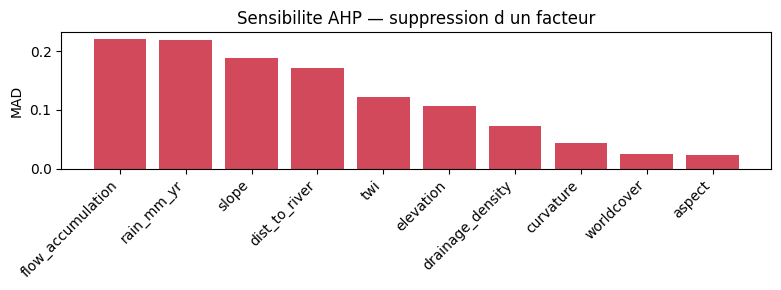

In [11]:
# --- ETAPE 7 : Analyse de sensibilite ---
sens_df = sensitivity_analysis(SCORES, weights, fips)
print("Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :")
print(sens_df.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.bar(sens_df["criterion"], sens_df["MAD_FIPS"], color="#d1495b")
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAD")
plt.title("Sensibilite AHP — suppression d un facteur")
plt.tight_layout()
plt.show()


In [ ]:
FORAGES_PATH = "data/ForagesMono.csv"          

df = pd.read_csv(FORAGES_PATH)             
df = df.rename(columns={"xCoord": "lon", "yCoord": "lat"})   

LON_COL = "lon" 
LAT_COL = "lat" 

print(f"{len(df)} forages chargés | colonnes : {list(df.columns)}")
print(df[[LON_COL, LAT_COL]].describe())

In [26]:
def load_forages(path, sep=",", lon_col="xCoord", lat_col="yCoord", source_name=None):
    """Charge un fichier CSV de forages et extrait la zone de risque à chaque point."""
    d = pd.read_csv(path, sep=sep)
    d = d.rename(columns={lon_col: "lon", lat_col: "lat"})
    d["source"] = source_name or path

    lon_min, lon_max, lat_min, lat_max = ext
    h, w = zones.shape

    def to_px(lon, lat):
        col = int((lon - lon_min) / (lon_max - lon_min) * (w - 1))
        row = int((lat_max - lat) / (lat_max - lat_min) * (h - 1))
        return row, col

    rs, cs = zip(*[to_px(lo, la) for lo, la in zip(d["lon"], d["lat"])])
    rs, cs = np.array(rs), np.array(cs)

    in_b = (rs >= 0) & (rs < h) & (cs >= 0) & (cs < w)
    rs_s = np.clip(rs, 0, h - 1)
    cs_s = np.clip(cs, 0, w - 1)

    d["zone_risque"]  = np.where(in_b, zones[rs_s, cs_s], np.nan)
    d["fips"]         = np.where(in_b, fips[rs_s,  cs_s], np.nan)
    d["in_bounds"]    = in_b
    return d

zone_labels = {1: "Very low", 2: "Low", 3: "Moderate",
               4: "High", 5: "Very high"}

df_mono = load_forages("data/ForagesMono.csv", sep=",",  source_name="Benin")
df_togo = load_forages("data/Togo.csv",        sep=",",  source_name="Togo")

for label, df_ in [("ForagesMono", df_mono), ("Togo", df_togo)]:
    n_in  = df_["in_bounds"].sum()
    n_out = (~df_["in_bounds"]).sum()
    print(f"\n── {label} : {len(df_)} forages ({n_in} dans l'emprise, {n_out} hors emprise)")
    counts = df_["zone_risque"].map(zone_labels).value_counts().sort_index()
    print(counts.to_string())


── ForagesMono : 1763 forages (1314 dans l'emprise, 449 hors emprise)
zone_risque
High         25
Low         571
Moderate    495
Very low      8

── Togo : 1558 forages (1367 dans l'emprise, 191 hors emprise)
zone_risque
High         63
Low         693
Moderate    438
Very low     81


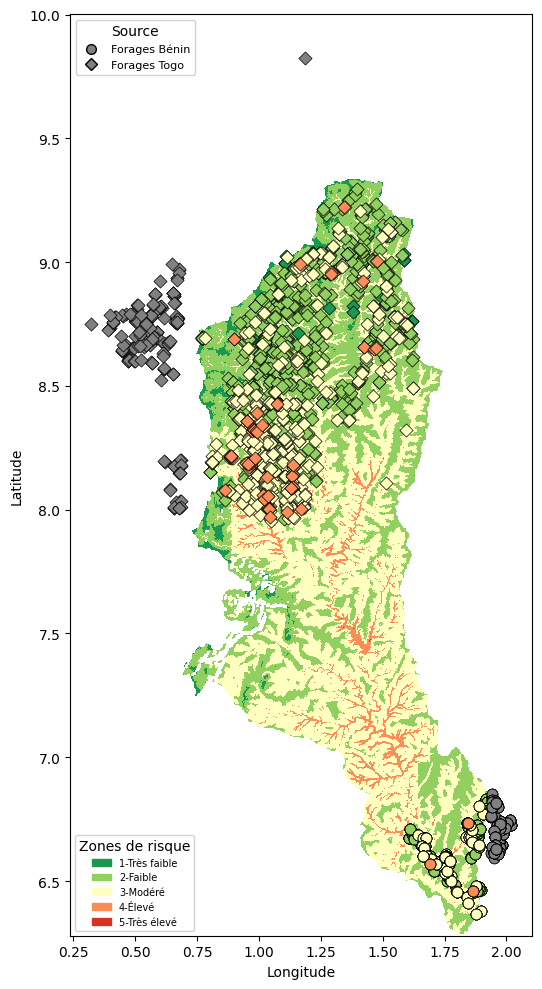

Exporté → data/ForagesMono_risque.csv
Exporté → data/Togo_risque.csv


In [ ]:
zone_colors = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
cmap_zones  = ListedColormap(zone_colors)
cmap_zones.set_bad(alpha=0)

# Configurations visuelles par source
DATASETS = [
    {"df": df_mono, "marker": "o", "size": 60,  "label": "ForagesMono"},
    {"df": df_togo, "marker": "D", "size": 45,  "label": "Togo"},
]

fig, ax = plt.subplots(figsize=(7, 10))

# Fond : zones de risque
ax.imshow(zones, cmap=cmap_zones, vmin=0.5, vmax=5.5,
          extent=[lon_min, lon_max, lat_min, lat_max], origin="upper")

# Forages — une série par (source × zone)
for ds in DATASETS:
    df_  = ds["df"]
    mkr  = ds["marker"]
    sz   = ds["size"]
    src  = ds["label"]
    for zone_id, color in zip([1, 2, 3, 4, 5], zone_colors):
        mask = df_["zone_risque"] == zone_id
        if mask.any():
            ax.scatter(df_.loc[mask, "lon"], df_.loc[mask, "lat"],
                       c=color, edgecolors="black", linewidths=0.5,
                       s=sz, marker=mkr, zorder=5)
    # Forages hors emprise
    hors = ~df_["in_bounds"]
    if hors.any():
        ax.scatter(df_.loc[hors, "lon"], df_.loc[hors, "lat"],
                   c="grey", edgecolors="black", linewidths=0.5,
                   s=sz, marker=mkr, zorder=5)

# ── Légende 1 : zones de risque (couleurs)
patches_zones = [mpatches.Patch(color=zone_colors[i], label=list(zone_labels.values())[i])
                 for i in range(5)]                   #label=f"Zone {i+1} — {list(zone_labels.values())[i]}"
leg1 = ax.legend(handles=patches_zones, title="Zones de risque",
                 loc="lower left", fontsize=7, framealpha=0.85)
ax.add_artist(leg1)

# ── Légende 2 : source des forages (forme du marqueur)
import matplotlib.lines as mlines
handles_src = [
    mlines.Line2D([], [], color="grey", marker="o", linestyle="None",
                  markersize=7, markeredgecolor="black", label="Forages Bénin"),
    mlines.Line2D([], [], color="grey", marker="D", linestyle="None",
                  markersize=6, markeredgecolor="black", label="Forages Togo"),
]
ax.legend(handles=handles_src, title="Source", loc="upper left",
          fontsize=8, framealpha=0.85)

#ax.set_title("Forages — Zones de risque d'inondation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

"""
# Export
for ds in DATASETS:
    out = f"data/{ds['label']}_risque.csv"
    ds["df"].drop(columns=["in_bounds"]).to_csv(out, index=False)
    print(f"Exporté → {out}")
"""

In [ ]:
out_path = "data/forages_risque.csv"
df.drop(columns=["row_px", "col_px"]).to_csv(out_path, index=False)
print(f"\nRésultats exportés → {out_path}")


In [25]:
import numpy as np

# Liste des facteurs correspondante à tes index
factors = [
    "0. elevation", "1. slope", "2. aspect", "3. curvature", "4. dist_to_river",
    "5. drainage_density", "6. twi", "7. flow_accumulation", "8. worldcover", "9. rain"
]

n = len(factors)
matrix = np.ones((n, n))

# Tes jugements (partie inférieure de la matrice)
AHP_PAIRS = {
    (1, 0): 1, (2, 0): 1/5, (2, 1): 1/7, (3, 0): 1/3, (3, 1): 1/3, (3, 2): 2,
    (4, 0): 2, (4, 1): 1, (4, 2): 7, (4, 3): 5, (5, 0): 1/2, (5, 1): 1/2,
    (5, 2): 5, (5, 3): 3, (5, 4): 1/3, (6, 0): 2, (6, 1): 2, (6, 2): 9,
    (6, 3): 5, (6, 4): 1, (6, 5): 3, (7, 0): 2, (7, 1): 1, (7, 2): 9,
    (7, 3): 5, (7, 4): 1, (7, 5): 3, (7, 6): 1, (8, 0): 1/3, (8, 1): 1/3,
    (8, 2): 3, (8, 3): 2, (8, 4): 1/5, (8, 5): 1/2, (8, 6): 1/5, (8, 7): 1/5,
    (9, 0): 2, (9, 1): 2, (9, 2): 7, (9, 3): 5, (9, 4): 1/2, (9, 5): 2,
    (9, 6): 1/2, (9, 7): 1/2, (9, 8): 3
}

# Remplissage de la matrice
for (i, j), value in AHP_PAIRS.items():
    matrix[i, j] = value
    matrix[j, i] = 1 / value

# Calcul des poids (Méthode de la moyenne normalisée par colonne)
col_sums = matrix.sum(axis=0)
norm_matrix = matrix / col_sums
weights = norm_matrix.mean(axis=1)

# Calcul du Ratio de Cohérence (CR)
lambda_max = np.real(np.linalg.eigvals(matrix).max())
ci = (lambda_max - n) / (n - 1)
# Indice aléatoire (RI) pour n=10 est généralement admis à 1.49
ri = 1.49
cr = ci / ri

print("--- POIDS DES FACTEURS ---")
for factor, weight in zip(factors, weights):
    print(f"{factor}: {weight:.4f} ({weight*100:.2f}%)")

print("\n--- ANALYSE DE COHÉRENCE ---")
print(f"Lambda Max : {lambda_max:.4f}")
print(f"Indice de Cohérence (CI) : {ci:.4f}")
print(f"Ratio de Cohérence (CR) : {cr:.4f} ({cr*100:.2f}%)")

if cr < 0.10:
    print("-> Succès ! La matrice est cohérente (CR < 10%).")
else:
    print("-> Attention ! La matrice est incohérente (CR >= 10%). Tu devrais ajuster certaines paires.")

--- POIDS DES FACTEURS ---
0. elevation: 0.0922 (9.22%)
1. slope: 0.1129 (11.29%)
2. aspect: 0.0170 (1.70%)
3. curvature: 0.0297 (2.97%)
4. dist_to_river: 0.1667 (16.67%)
5. drainage_density: 0.0642 (6.42%)
6. twi: 0.1810 (18.10%)
7. flow_accumulation: 0.1703 (17.03%)
8. worldcover: 0.0389 (3.89%)
9. rain: 0.1270 (12.70%)

--- ANALYSE DE COHÉRENCE ---
Lambda Max : 10.2475
Indice de Cohérence (CI) : 0.0275
Ratio de Cohérence (CR) : 0.0185 (1.85%)
-> Succès ! La matrice est cohérente (CR < 10%).
